# Simulation

> Simulate from fitted parameters and generate benchmark diagnostics.

## Overview

Load fitted model parameters (from a single JSON or a directory of per-subject
partial JSONs), simulate recall sequences, and compare model predictions against
empirical data using standard behavioural benchmarks (SPC, CRP, PNR, etc.).

In [1]:
import glob
import inspect
import json
import os
import re
import warnings
from pathlib import Path
from typing import Any, Mapping, Sequence, cast

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from jax import random
from matplotlib import rcParams  # type: ignore

from jaxcmr import repetition
from jaxcmr.helpers import (
    find_project_root,
    generate_trial_mask,
    import_from_string,
    load_data,
    save_dict_to_hdf5,
    save_figure,
)
from jaxcmr.simulation import simulate_h5_from_h5
from jaxcmr.typing import TrialSimulator

warnings.filterwarnings("ignore")

In [2]:
# Data parameters
data_path = "data/HealeyKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
embedding_path = ""
emotion_feature_path = ""
feature_column = 6
concat_features = False
trial_query = "data['listtype'] == -1"
target_directory = "results/"
experiment_count = 10
max_subjects = 0

# Model configuration
make_factory_path = "jaxcmr.models.cmr.make_factory"
component_paths = {
    "mfc_create_fn": "jaxcmr.components.linear_memory.init_mfc",
    "mcf_create_fn": "jaxcmr.components.linear_memory.init_mcf",
    "context_create_fn": "jaxcmr.components.context.init",
    "termination_policy_create_fn": "jaxcmr.components.termination.NoStopTermination",
}
sim_alg_path = "jaxcmr.simulation.simulate_study_free_recall_and_forced_stop"

# Fit results — path to a JSON file or a directory of partial JSONs
fit_path = "results/fits/HealeyKahana2014_WeirdCMRNoStop_fixed_term_best_of_1.json"

# Fitting mode (controls param broadcasting for simulation)
pooled = False

# Flow toggles
filter_repeated_recalls = True
redo_sims = True
redo_figures = True

# hyperparameters
seed = 0

# analysis configuration
comparison_analysis_configs = [
    {
        "target": "jaxcmr.analyses.nth_item_recall.plot_conditional_nth_item_recall_curve",
        "kwargs": {"query_study_position": 1},
    },
    {
        "target": "jaxcmr.analyses.nth_item_recall.plot_conditional_nth_item_recall_curve"
    },
    {"target": "jaxcmr.analyses.nth_item_recall.plot_simple_nth_item_recall_curve"},
    {"target": "jaxcmr.analyses.spc.plot_spc"},
    {"target": "jaxcmr.analyses.crp.plot_crp"},
    {"target": "jaxcmr.analyses.pnr.plot_pnr"},
    {"target": "jaxcmr.analyses.termination_probability.plot_termination_probability"},
]

single_analysis_configs = []

In [3]:
rng = random.PRNGKey(seed)

# resolve paths against project root
project_root = Path(find_project_root())
target_directory = os.path.join(project_root, target_directory)
figure_dir = os.path.join(project_root, figure_dir)

# derive fit stem from fit_path (used for sim output naming)
fit_path = os.path.join(project_root, fit_path)
fit_stem = Path(fit_path).stem

# set up product directories
product_dirs = {}
for product, subdir in {"figures": "figures/fitting", "simulations": "simulations"}.items():
    product_dir = os.path.join(target_directory, subdir)
    product_dirs[product] = product_dir
    if not os.path.exists(product_dir):
        os.makedirs(product_dir)

# load data
data = load_data(os.path.join(project_root, data_path), max_subjects)
trial_mask = generate_trial_mask(data, trial_query)

# load feature blocks
semantic_features = None
if embedding_path:
    semantic_features = np.load(project_root / embedding_path).astype(np.float32)

categorical_column = None
if emotion_feature_path:
    emotion_features = np.load(project_root / emotion_feature_path).astype(np.float32)
    categorical_column = emotion_features[:, feature_column : feature_column + 1]

modeling_features = semantic_features
if concat_features:
    modeling_features = np.concatenate([categorical_column, semantic_features], axis=1)  # type: ignore

# import analyses
comparison_analyses = []
for config in comparison_analysis_configs:
    analysis_fn = import_from_string(config["target"])
    figure_suffix = config.get("figure_suffix")
    if figure_suffix is None:
        name = getattr(analysis_fn, "__name__", "analysis")
        figure_suffix = name[5:] if name.startswith("plot_") else name
    labels = tuple(cast(Sequence[str], config.get("labels", ("Model", "Data"))))
    contrast_name = config.get("contrast_name", "Source")
    extra_kwargs = dict(cast(Mapping[str, Any], config.get("kwargs", {})))

    analysis_name = analysis_fn.__name__
    if "dist_" in analysis_name and semantic_features is not None:
        extra_kwargs.setdefault("features", semantic_features)
    elif "cat_" in analysis_name and categorical_column is not None:
        extra_kwargs.setdefault("features", categorical_column)

    comparison_analyses.append(
        {
            'target': analysis_fn,
            'figure_suffix': str(figure_suffix),
            'labels': labels,
            'contrast_name': str(contrast_name),
            'kwargs': extra_kwargs,
            'ylim': config.get('ylim', None),
            'color_cycle': config.get('color_cycle', None)
        }
    )

single_analyses = []
for config in single_analysis_configs:
    analysis_fn = import_from_string(config["target"])
    figure_suffix = config.get("figure_suffix")
    if figure_suffix is None:
        name = getattr(analysis_fn, "__name__", "analysis")
        figure_suffix = name[5:] if name.startswith("plot_") else name
    labels = tuple(cast(Sequence[str], config.get("labels", ("Model",))))
    contrast_name = config.get("contrast_name", "Source")
    extra_kwargs = dict(cast(Mapping[str, Any], config.get("kwargs", {})))

    analysis_name = analysis_fn.__name__
    if "dist_" in analysis_name and semantic_features is not None:
        extra_kwargs.setdefault("features", semantic_features)
    elif "cat_" in analysis_name and categorical_column is not None:
        extra_kwargs.setdefault("features", categorical_column)

    single_analyses.append(
        {
            'target': analysis_fn,
            'figure_suffix': str(figure_suffix),
            'labels': labels,
            'contrast_name': str(contrast_name),
            'kwargs': extra_kwargs,
            'ylim': config.get('ylim', None),
            'color_cycle': config.get('color_cycle', None)
        }
    )

# configure model factory
make_factory = import_from_string(make_factory_path)
model_factory_cls = make_factory(
    **{key: import_from_string(path) for key, path in component_paths.items()}
)

simulate_trial_fn: TrialSimulator = import_from_string(sim_alg_path)

## Load fit results

In [4]:
fit_path = Path(fit_path)

if fit_path.is_file():
    with fit_path.open() as handle:
        results = json.load(handle)
    print(f"Loaded fit results from {fit_path}")

elif fit_path.is_dir():
    partial_paths = sorted(
        glob.glob(str(fit_path / "*.json")),
        key=lambda p: [int(s) for s in re.findall(r"sub(\d+)", p)] or [0],
    )
    if not partial_paths:
        raise FileNotFoundError(f"No JSON files found in {fit_path}")

    partials = []
    for p in partial_paths:
        with open(p) as handle:
            partials.append(json.load(handle))

    # Merge: take structure from first partial, concatenate per-subject data
    results = {
        "fixed": partials[0]["fixed"],
        "free": partials[0]["free"],
        "hyperparameters": partials[0]["hyperparameters"],
        "fitness": [],
        "fits": {k: [] for k in partials[0]["fits"]},
        "fit_time": sum(p["fit_time"] for p in partials),
    }
    for p in partials:
        results["fitness"] += p["fitness"]
        for k in results["fits"]:
            results["fits"][k] += p["fits"][k]

    # Copy metadata from first partial
    for key in partials[0]:
        if key not in results:
            results[key] = partials[0][key]

    print(f"Merged {len(partials)} partial results from {fit_path}")

else:
    raise FileNotFoundError(f"fit_path not found: {fit_path}")

Loaded fit results from /Users/jordangunn/workspace/jaxcmr/results/fits/HealeyKahana2014_WeirdCMRNoStop_fixed_term_best_of_1.json


## Simulate from fitted parameters

In [5]:
sim_path = os.path.join(product_dirs["simulations"], f"{fit_stem}.h5")
print(sim_path)

rng, rng_iter = random.split(rng)
params = {key: jnp.array(val) for key, val in results["fits"].items()}  # type: ignore

if pooled:
    unique_subjects = jnp.unique(jnp.array(data["subject"]))
    n_subjects = unique_subjects.shape[0]
    params = {
        key: jnp.repeat(val, n_subjects) if key != "subject" else unique_subjects
        for key, val in params.items()
    }

if os.path.exists(sim_path) and not redo_sims:
    sim = load_data(sim_path)
    print(f"Loaded from {sim_path}")

else:
    sim = simulate_h5_from_h5(
        model_factory_cls,
        data,
        modeling_features,
        params,
        trial_mask,
        experiment_count,
        rng_iter,
        simulate_trial_fn=simulate_trial_fn,
    )

    save_dict_to_hdf5(sim, sim_path)  # type: ignore
    print(f"Saved to {sim_path}")

if filter_repeated_recalls:
    sim["recalls"] = repetition.filter_repeated_recalls(sim["recalls"])

/Users/jordangunn/workspace/jaxcmr/results/simulations/HealeyKahana2014_WeirdCMRNoStop_fixed_term_best_of_1.h5
Saved to /Users/jordangunn/workspace/jaxcmr/results/simulations/HealeyKahana2014_WeirdCMRNoStop_fixed_term_best_of_1.h5


## Figures

In [6]:
#|code-summary: single-dataset views

for analysis_cfg in single_analyses:
    analysis_fn = analysis_cfg["target"]
    analysis_suffix = analysis_cfg["figure_suffix"]

    trial_mask = generate_trial_mask(data, trial_query)
    sim_trial_mask = generate_trial_mask(sim, trial_query)

    for dataset_label, (dataset, trial_mask) in zip(
        ["data", "sim"], [(data, trial_mask), (sim, sim_trial_mask)]
    ):

        if analysis_cfg.get("color_cycle") is None:
            color_cycle = [each["color"] for each in rcParams["axes.prop_cycle"]]
        else:
            color_cycle = analysis_cfg["color_cycle"].copy()

        base_kwargs = {
            "datasets": dataset,
            "trial_masks": np.array(trial_mask),
            "color_cycle": color_cycle,
            "labels": list(analysis_cfg["labels"]),
            "contrast_name": analysis_cfg["contrast_name"],
            "axis": None,
        }
        base_kwargs |= analysis_cfg["kwargs"]

        signature = inspect.signature(analysis_fn)
        filtered_kwargs = {
            name: value
            for name, value in base_kwargs.items()
            if name in signature.parameters
        }

        figure_path = (
            os.path.join(
                figure_dir, f"{figure_str}_{analysis_suffix}_{dataset_label}.png"
            )
            if figure_str
            else None
        )
        if figure_path and os.path.exists(figure_path) and not redo_figures:
            display(Image(filename=figure_path))
            continue

        axis = analysis_fn(**filtered_kwargs)

        if analysis_cfg["ylim"] is not None:
            plt.ylim(analysis_cfg["ylim"])

        if figure_path:
            print(f"![]({figure_path})")
        save_figure(
            figure_dir,
            figure_str,
            suffix=f"{analysis_suffix}_{dataset_label}",
        )

plot_conditional_nth_item_recall_curve


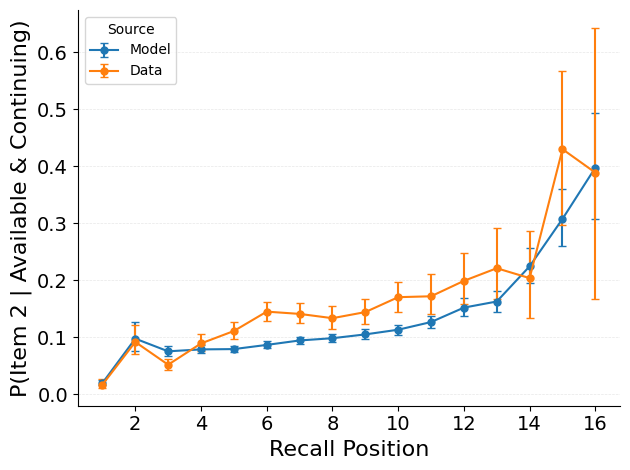

plot_conditional_nth_item_recall_curve


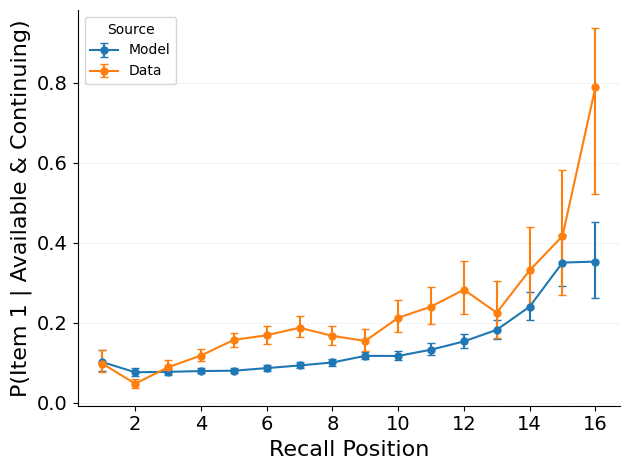

plot_simple_nth_item_recall_curve


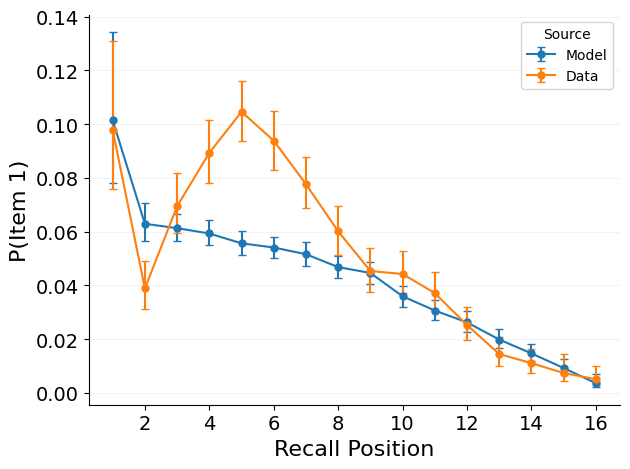

plot_spc


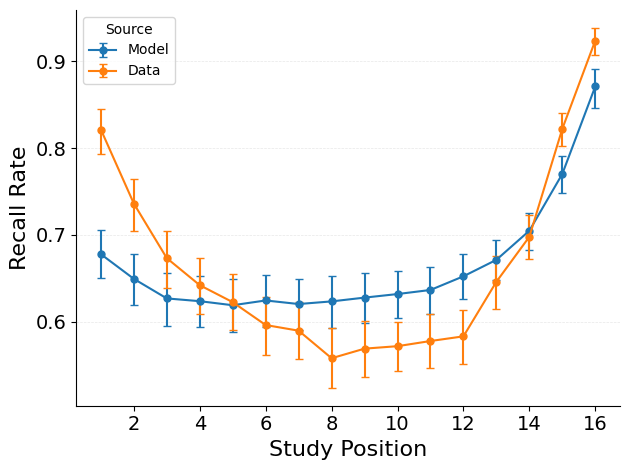

plot_crp


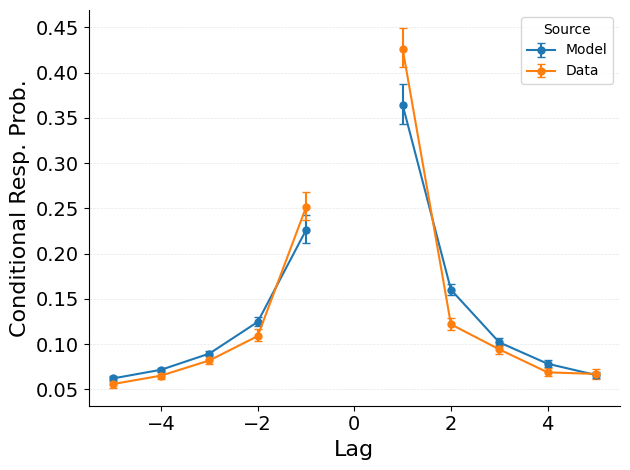

plot_pnr


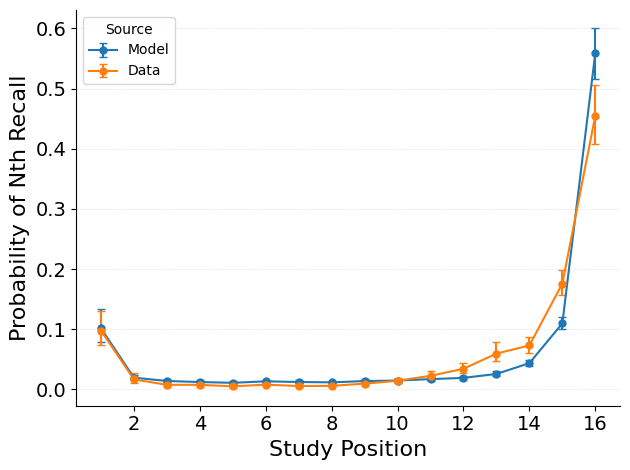

plot_termination_probability


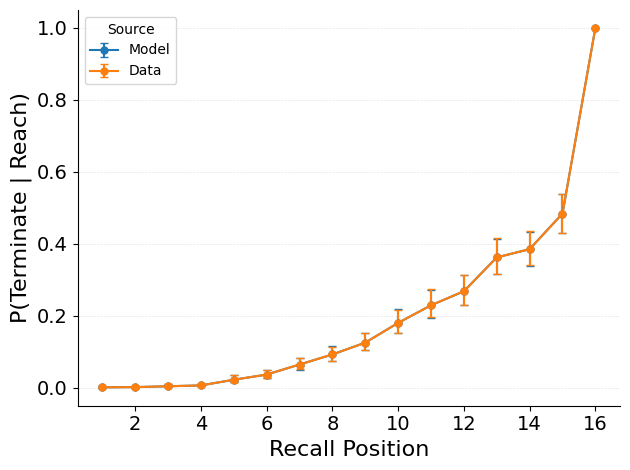

In [7]:
# generate figures comparing model and data
for analysis_cfg in comparison_analyses:
    analysis_fn = analysis_cfg['target']
    analysis_suffix = analysis_cfg["figure_suffix"]
    figure_path = os.path.join(figure_dir, f"{figure_str}_{analysis_suffix}.png") if figure_str else None
    if figure_path:
        print(f"![]({figure_path})")

    if figure_path and os.path.exists(figure_path) and not redo_figures:
        display(Image(filename=figure_path))
        continue

    if analysis_cfg.get('color_cycle') is None:
        color_cycle = [each["color"] for each in rcParams["axes.prop_cycle"]]
    else:
        color_cycle = analysis_cfg['color_cycle'].copy()

    trial_mask = generate_trial_mask(data, trial_query)
    sim_trial_mask = generate_trial_mask(sim, trial_query)

    base_kwargs = {
        "datasets": [sim, data],
        "trial_masks": [np.array(sim_trial_mask), np.array(trial_mask)],
        "color_cycle": color_cycle,
        "labels": list(analysis_cfg['labels']),
        "contrast_name": analysis_cfg['contrast_name'],
        "axis": None,
    }
    base_kwargs |= analysis_cfg['kwargs']

    signature = inspect.signature(analysis_fn)
    print(analysis_fn.__name__)
    filtered_kwargs = {
        name: value
        for name, value in base_kwargs.items()
        if name in signature.parameters
    }

    axis = analysis_fn(**filtered_kwargs)

    if analysis_cfg.get('ylim') is not None:
        axis.set_ylim(analysis_cfg['ylim'])
    save_figure(figure_dir, figure_str, suffix=analysis_suffix)